 RSNA Total DICOM files: 26684
   Image shape: (1024, 1024)
   Modality: CR

 Tamper Dataset contents:
   content_removal: 1 files
   copy_move: 1 files
   copy_paste: 1 files
   original: 1 files
   text_addition: 1 files

 Brain MRI Dataset contents:
   Testing: 0 images
   Training: 0 images


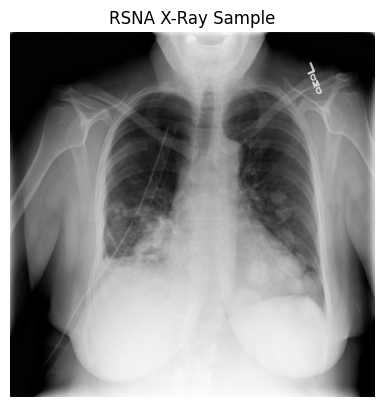


 Exploration complete! Check results/plots/dataset_samples.png


In [6]:
import os
import pydicom
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ============================================================
# PART A — Explore RSNA X-Ray (DICOM files)
# ============================================================

rsna_path = r"..\data\raw\rsna-pneumonia-detection-challenge\stage_2_train_images"  

dicom_files = [f for f in os.listdir(rsna_path) if f.endswith('.dcm')]
print(f" RSNA Total DICOM files: {len(dicom_files)}")

# Load and display one sample
sample_dcm = pydicom.dcmread(os.path.join(rsna_path, dicom_files[0]))
print(f"   Image shape: {sample_dcm.pixel_array.shape}")
print(f"   Modality: {sample_dcm.Modality}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_dcm.pixel_array, cmap='gray')
plt.title("RSNA X-Ray Sample")
plt.axis('off')


# ============================================================
# PART B — Explore Tamper Dataset
# ============================================================

tamper_path = r"..\data\raw\Tamper Dataset/"
print(f"\n Tamper Dataset contents:")
for folder in os.listdir(tamper_path):
    folder_path = os.path.join(tamper_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"   {folder}: {count} files")

# Display one tampered image
# (adjust folder name after you see the actual structure)
tamper_folders = os.listdir(tamper_path)
if tamper_folders:
    first_folder = os.path.join(tamper_path, tamper_folders[0])
    sample_files = [f for f in os.listdir(first_folder)
                    if f.endswith(('.png', '.jpg', '.jpeg'))]
    if sample_files:
        img = Image.open(os.path.join(first_folder, sample_files[0]))
        plt.subplot(1, 3, 2)
        plt.imshow(img)
        plt.title(f"Tamper Dataset\n({tamper_folders[0]})")
        plt.axis('off')


# ============================================================
# PART C — Explore Brain MRI
# ============================================================

mri_path = r"..\data\raw\Brain MRI"
print(f"\n Brain MRI Dataset contents:")
for folder in os.listdir(mri_path):
    folder_path = os.path.join(mri_path, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path)
                     if os.path.isfile(os.path.join(folder_path, f))])
        print(f"   {folder}: {count} images")

# Display a brain MRI sample
for folder in os.listdir(mri_path):
    folder_path = os.path.join(mri_path, folder)
    if os.path.isdir(folder_path):
        imgs = [f for f in os.listdir(folder_path)
                if f.endswith(('.png', '.jpg'))]
        if imgs:
            img = Image.open(os.path.join(folder_path, imgs[0]))
            plt.subplot(1, 3, 3)
            plt.imshow(img, cmap='gray')
            plt.title(f"Brain MRI Sample\n({folder})")
            plt.axis('off')
            break

plt.tight_layout()
plt.savefig("../results/plots/dataset_samples.png")
plt.show()
print("\n Exploration complete! Check results/plots/dataset_samples.png")